# 2. Structure of the HDF5 output file

PlatoSim produces three output files:

* an **HDF5** file which is the subject of this notebook
* a **log** file which contains all info, warning, error, and debugging messages
* a copy of the **YAML** input file

We will assume in this notebook that you run PlatoSim and inspect the HDF5 output file from a python environment. The HDF5 file is located in the directory specified in `sim.outputDir`.

<img src="StructureOfPlatoSimHDF5.png">

The group `InputParameters` contains a copy of the configuration parameters from the YAML file. Not all parameters however have yet made it into the HDF5 output file, on-going work.

The group `StarPositions` contains - for each exposure - the pixel coordinates, planar focal plane coordinates, and the flux of the star with starID. The coordinates are averaged positions of the star over the duration of the exposure. Only the stars that fall within the subField during the exposure are stored, i.e. some stars may move out of the subField due to the spacecraft jitter.

The group `StarCatalog` contains the sky coordinates, the pixel coordinates, and the focal plane coordinates of all the stars that were detected during any exposure. The starIDs map the ID from the input starCatalog that was supplied with the configuration. Pixel coordinates and planar focal plane coordinates are initial values before any Jitter takes place.

In this tutorial we show how to inspect and extract information from the HDF5 output file produced by PlatoSim. We present how to use **h5py**, the in-build **h5** function, but we will place the effort on explaining how to fully utilise the in-build **SimFile** class.

Note: apart from the libraries show in this tutorial, it is also possible to investigate HDF(5) files with [PyTables](https://www.pytables.org/index.html), however, this packages is known to course problems with other packages used in PlatoSim and hence we avoid it for our dependencies.

### Setup notebook

In [1]:
# Reload code outside notebook
%load_ext autoreload
%autoreload 2

# Configure figures in notebook
%matplotlib notebook

### Imports

In [2]:
import os
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt

# PlatoSim
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.matplotlibrc import setup_notebook
setup_notebook()

### Run a default simulation for the tutorial

In [3]:
# Define inputs and outputs
outputDir      = os.getcwd()
outputFileName = "output_example1"
outputFile     = f"{outputDir}/{outputFileName}.hdf5"

# Generate simulation object and control the output
sim = Simulation(outputFileName, outputDir=outputDir)
sim["Camera/IncludeExtendedGhosts"]              = True
sim["ControlHDF5Content/WriteHighResolutionPSF"] = True
sim["ControlHDF5Content/WriteSubPixelImages"]    = True

# Run PlatoSim (and allow to overwrite output file)
sim.run(removeOutputFile=True);

---
## 2.1 - Inspect with [h5py](https://docs.h5py.org/en/stable/)
---

We here show a minimal example of using [h5py](https://docs.h5py.org/en/stable/) to inspect your HDF5 output file. E.g. let's fetch the first exposure simulated:

In [4]:
import h5py
h5file = h5py.File(outputFile, 'r')

In [5]:
# Get an image
im = h5file['Images/image000000'][:]
im

array([[1189, 1193, 1190, ..., 1191, 1184, 1186],
       [1196, 1194, 1195, ..., 1178, 1189, 1191],
       [1191, 1199, 1197, ..., 1185, 1184, 1185],
       ...,
       [1192, 1185, 1194, ..., 1192, 1190, 1194],
       [1188, 1182, 1182, ..., 1191, 1188, 1189],
       [1186, 1180, 1186, ..., 1183, 1192, 1197]], dtype=uint16)

---
## 2.2 - Inspect with h5
---

PlatoSim has an build-in functionality to use `h5py` to print the structure and fetch the information from the HDF5 output file:

In [6]:
from platosim.h5 import h5get, h5ls

### Function: h5ls

The function **h5ls** takes an HDF5 file object or a HDF5 group as a mandatory argument and shows the complete structure of the HDF5 file or group. Each level is indicated by the following type acronyms, and for attributes their value is shown.

[G] Group <br/>
[D] Dataset <br/>
[a] Attribute

Print the entire HDF5 file - equivalent to specifying only the root group `h5ls(h5file['/'])`:

In [7]:
h5ls(h5file)

[G] /ACS
[D]     /Pitch
[D]     /PlatformDec
[D]     /PlatformRA
[D]     /Roll
[D]     /Time
[D]     /Yaw
[G] /Background
[D]     /skyBackground
[G] /BiasMapsLeft
[D]     /biasMap000000
[D]     /biasMap000001
        ...
[D]     /biasMap000009
[G] /BiasMapsRight
[D]     /biasMap000000
[D]     /biasMap000001
        ...
[D]     /biasMap000009
[G] /CTI
[D]     /trapDensityMapForSpecies0BOL
[D]     /trapDensityMapForSpecies0EOL
        ...
[D]     /trapDensityMapForSpecies3EOL
[G] /Cosmics
[G]     /BiasMapLeft
[G]         /exposure000000
[D]             /Columns
[D]             /EntryAngles
[D]             /EntryColumns
[D]             /EntryRows
[D]             /Flux
[D]             /Intensities
[D]             /Rows
[D]             /TrailLengths
[G]         /exposure000001
[D]             /Columns
[D]             /EntryAngles
[D]             /EntryColumns
[D]             /EntryRows
[D]             /Flux
[D]             /Intensities
[D]             /Rows
[D]             /TrailLengths
   

In [8]:
# Example of a Dataset
h5ls(h5file['BiasMapsLeft'])

[D] /biasMap000000
[D] /biasMap000001
    ...
[D] /biasMap000009


In [9]:
# Example of attributes
h5ls(h5file['InputParameters/CCD/Gain'])

[a] /AllowedDifference      15.0
[a] /     RefValueLeft      2.14
[a] /    RefValueRight      2.14
[a] /        Stability      -0.001


### Function: h5get

With **h5get** you can get data out of the HDF5 file into numpy arrays or python variables. This function takes two mandatory arguments, the HDF5 file object (or group) and the 'path into the variable or dataset'.

When you specify the full path, only that variable is returned as shown in the following two commands. When you specify a partial path or just the name of the final dataset/attribute, the **h5get** function looks for all possible matches and returns an array with their values. This is illustrated further with 'ReadoutNoise'.

In [10]:
pos = h5get(h5file, "/InputParameters/CCD/Position", verbose=False)
print ("Type and value of Position: {}, {}".format(type(pos), pos))

Type and value of Position: <class 'str'>, Custom


In [11]:
noise = h5get(h5file, "/InputParameters/CCD/ReadoutNoise", verbose=False)
print ("Type and value of ReadoutNoise: {}, {}".format(type(noise), noise))

Type and value of ReadoutNoise: <class 'numpy.float64'>, 38.7


In [12]:
h5get(h5file, "ReadoutNoise")

selection strings: ['ReadoutNoise']
matching items:
    Attribute       /InputParameters/CCD/IncludeReadoutNoise
    Attribute       /InputParameters/CCD/ReadoutNoise
    Attribute       /InputParameters/FEE/ReadoutNoise
    Attribute       /InputParameters/RandomSeeds/ReadOutNoiseSeed


[1, 38.7, 32.0, 1424949740]

In [13]:
cols = h5get(h5file, "InputParameters/CCD/NumColumns", verbose=False)
print ("Type and value of NumColumns: {}, {}".format(type(cols), cols))

Type and value of NumColumns: <class 'numpy.int32'>, 4510


In [14]:
dec = h5get(h5file, "ACS/PlatformDec", verbose=False)
ra  = h5get(h5file, "ACS/PlatformRA", verbose=False)
print ("Type and shape of RA : {}, {}".format(type(ra), ra.shape))
print ("Type and shape of Dec: {}, {}".format(type(dec), dec.shape))

Type and shape of RA : <class 'numpy.ndarray'>, (10,)
Type and shape of Dec: <class 'numpy.ndarray'>, (10,)


In [15]:
im = h5get(h5file,"Images/image000000", verbose=False)
im

array([[1189, 1193, 1190, ..., 1191, 1184, 1186],
       [1196, 1194, 1195, ..., 1178, 1189, 1191],
       [1191, 1199, 1197, ..., 1185, 1184, 1185],
       ...,
       [1192, 1185, 1194, ..., 1192, 1190, 1194],
       [1188, 1182, 1182, ..., 1191, 1188, 1189],
       [1186, 1180, 1186, ..., 1183, 1192, 1197]], dtype=uint16)

---
## 2.3 - Inspect with SimFile
---

In the previous tutorials we already touched upon how you can use the PlatoSim `SimFile` class to retrieve information from the HDF5 output file. Here we dive in a bit deeper and show must of its functionalites. First let's get the HDF5 file with:

In [16]:
f = SimFile(outputFileName + ".hdf5")

`reload()`: If you accidentially overwrites/mess up some parameters, you can always reload the HDF5 output again using: 

In [17]:
f.reload()

For the sake of this tutorial we will only inspect the first exposure, hence:

In [18]:
imageNr = 0

### Input Parameters

`getInputParameter()`: We here give a minimal example to show how to inspect one of the input parameters that was used for the simulation. The group name and parameter name are exactly the same as in the YAML file. E.g. fetch the `CycleTime`:

In [19]:
f.getInputParameter("ObservingParameters", "CycleTime")

25.0

`getExposureTime()`: Get the exposure time:

In [20]:
t_exp = f.getExposureTime()
t_exp

24.5941

`getReadoutTime()`: Get the readout time before the next exposure starts and the readout time during the next exposure. Note that this function automatically access which camera (*Normal* or *Fast*) has been used in the simulation:

In [21]:
t_out_before, t_out_after = f.getReadoutTime()
t_out_before, t_out_after

(0.4059, 0.026607000000000002)

``getTime()``: Get time column of all exposures:

In [22]:
time = f.getTime()[:]
time

,time
0,0.0
1,25.0
2,50.0
3,75.0
4,100.0
5,125.0
6,150.0
7,175.0
8,200.0
9,225.0


### Pointing, Jitter, and Drift

`getPlatformPointingCoordinates()`: Get the platform jitter in either equatorial coordinates (RA, Dec):

In [23]:
RA, Dec = f.getPlatformPointingCoordinates()

<IPython.core.display.Javascript object>


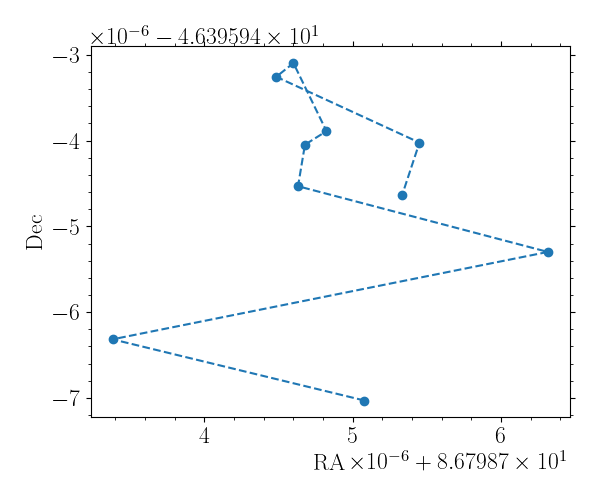

In [24]:
plt.figure(figsize=(6,5))
plt.plot(RA, Dec, 'o--')
plt.xlabel("RA")
plt.ylabel("Dec")
plt.tight_layout()
plt.show()

 `getYawPitchRoll()`: Or in the spacecraft rotation angles (yaw, pitch, roll):

In [25]:
yaw, pitch, roll = f.getYawPitchRoll()

<IPython.core.display.Javascript object>


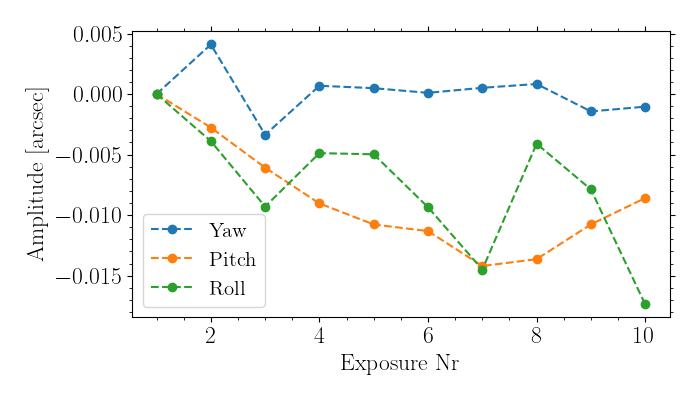

In [26]:
plt.figure(figsize=(7,4))
exp = np.arange(1,11,1)
plt.plot(exp, yaw,   'o--', label="Yaw")
plt.plot(exp, pitch, 'o--', label="Pitch")
plt.plot(exp, roll,  'o--', label="Roll")
plt.xlabel("Exposure Nr")
plt.ylabel("Amplitude [arcsec]")
plt.tight_layout()
plt.legend()
plt.show()

### Background and Stray light

`getPointLikeGhostCoordinates()`: Get information about the point-like ghosts:

In [27]:
ID, row, col, Xmm, Ymm, flux = f.getPointLikeGhostCoordinates(imageNr)
ID

Error: SimfFile.getPointLikeGhostCoordinates(): Exposure000000 not in hdf5 file


`getExtendedGhostCoordinates()`: Get information about extended ghosts:

In [28]:
ID, row, col, Xmm, Ymm, flux, radius = f.getExtendedGhostCoordinates(imageNr)
ID

Error: SimfFile.getExtendedGhostCoordinates(): Exposure000000 not in hdf5 file


`getCosmicsInfo()`: You can also retrieve information about the cosmic rays added to each exposure. Since cosmic rays can be added to several image products, note that the `field` parameters can determines from what field the Cosmics should be returned: `SubField`, `BiasMapLeft`, `BiasMapRight` or `SmearingMap`. We here fetch the cosmic ray information for exposure 0 in the star image:

In [29]:
entryRows, entryColumns, entryAngles, intensities, trailLengths = f.getCosmicsInfo(imageNr, field="SubField")
intensities

array([2713.42797338, 2846.33624042, 2757.06097246, 4672.49700025,
       4027.23583537, 2848.27373497, 4900.9210059 , 2686.06134352,
       6426.90811723])

`getCosmicsAffectedPixels()`: Get knowledge about the pixels that are affected by cosmic rays:

In [30]:
row, col, flux = f.getCosmicsAffectedPixels(imageNr)
flux

array([ 580.02979183,  485.12457429,   57.26616577,  374.03059122,
        381.99655539,   58.59340843,   34.12154532, 2330.45348039,
        402.66769772,   68.93312337,   10.16039362,  714.88716929,
         31.28263061,  584.58370133,   53.31243638,  471.08706718,
         60.44208586,  306.25611661,   55.39307727,  198.2634641 ,
         41.80148191,  102.12441097,   27.8216014 ,   53.0834656 ,
         56.01334652, 1313.75922643, 1151.08859216,  126.48020732,
        759.58399441,  599.21543873,  125.9321382 ,  230.07526702,
        185.81859721,   44.35630063,   40.84933899,   34.32341636,
          5.00113629,   48.27803129, 1132.33207756,  992.12588639,
        315.68051195,  448.02024708,  516.4651551 ,  257.20972566,
         49.63386993,  160.1574733 ,   73.43893537,    7.10439074,
         22.47904021,    4.31049079, 2417.84859537,  425.16398459,
          5.261155  , 3185.42869118, 1411.9276835 ,  288.73976213,
         14.82486909,  604.17576893,  558.09205685,  475.18144

### Stellar information

`getStarCatalog()`: Get the catalogue of stars that have been detected on a CCD:

In [31]:
ID, RA, dec, Vmag, xFPmm, yFPmm, rowPix, colPix = f.getStarCatalog()
ID

array([ 40680,  40858,  40956,  40957,  41115,  41135,  41175,  41206,
        41234,  41400,  41429,  41579,  41663,  41677,  41712,  41871,
        41876,  41889,  41932,  41994,  42012,  42201,  42287,  42376,
        42477,  42537,  42635,  42671,  42813,  42910,  42962,  43001,
       288113, 288611, 288884, 288885, 288886, 288887, 289337, 289338,
       289385, 289386, 289561, 289562, 289563, 289630, 289631, 289632,
       290050, 290051, 290052, 290053, 290054, 290162, 290163, 290555,
       290782, 290825, 290903, 290904, 290905, 291326, 291327, 291328,
       291357, 291474, 291475, 291476, 291604, 291605, 291657, 291658,
       291659, 292418, 292419, 292420, 292421, 292422, 292423, 292670,
       292671, 293168, 293169, 293507, 293508, 293607, 293608, 293609,
       293981, 293982, 294309, 294310, 294311, 294435], dtype=uint32)

`getStarCoordinates()`: Get the stellar coordinates in focal plane as well (in pixel and mm in the CCD focal plane). It is also possible to only get the coordinates of stars within a certain magnitude range `[minVmag, maxVmag]` as we show in the following for exposre 0:

In [32]:
ID, row, col, Xmm, Ymm, flux = f.getStarCoordinates(imageNr, minVmag=10.0, maxVmag=12.0)
ID

array([41579, 41712, 41932, 41994, 42201, 42287, 42477], dtype=uint32)

### Subfield images

`getImage()`: Get the full simulated subfield and the image dimentions and use them as extentions:

In [33]:
image      = f.getImage(imageNr)
numRows    = f.getInputParameter("SubField", "NumRows")
numColumns = f.getInputParameter("SubField", "NumColumns")

Let's plot the result:

<IPython.core.display.Javascript object>


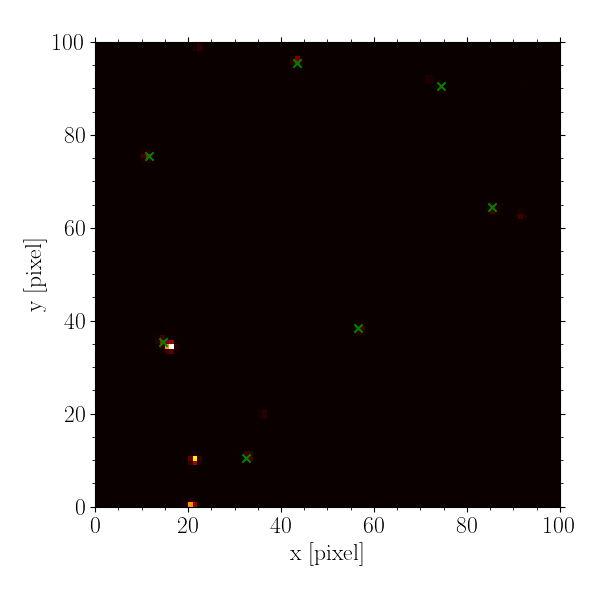

In [34]:
# Simple plot using imshow
plt.figure(figsize=(6,6))
plt.imshow(image, cmap=cm.hot, interpolation="nearest", origin='lower', extent=[0, numRows, 0, numColumns])
plt.scatter(np.floor(col)+0.5, np.floor(row)+0.5, marker='x', c='g')
plt.xlabel("x [pixel]")
plt.ylabel("y [pixel]")
plt.tight_layout()
plt.show()

Another options is to use the build-in function `showImage()` to visualize your subfield together with the stellar coordinates:

<IPython.core.display.Javascript object>


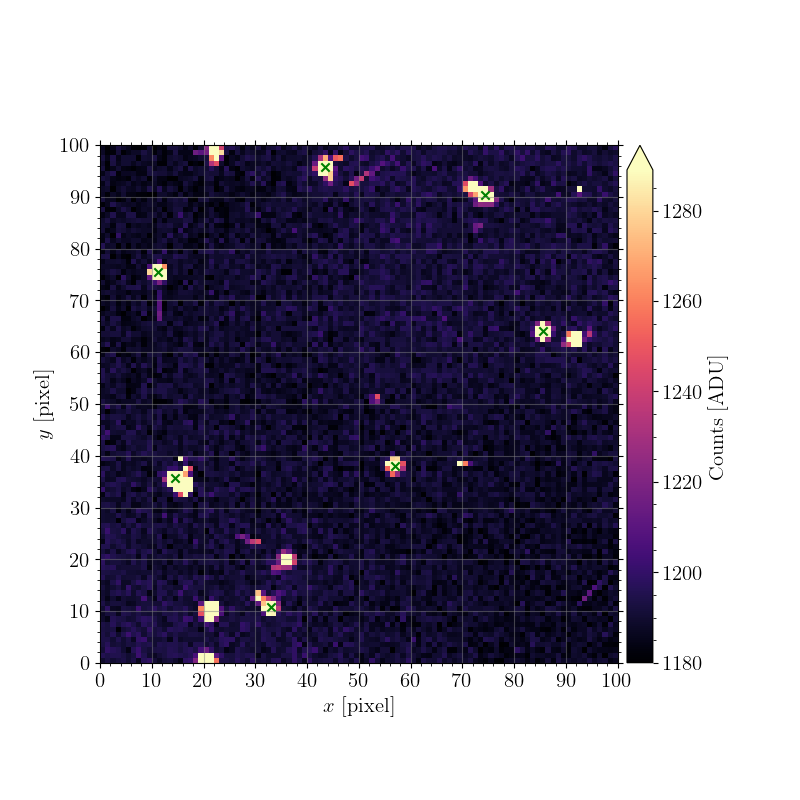

In [35]:
fig, ax = f.showImage(imageNr, clipPercentile=1, imgScale="clip",
                      minVmag=10.0, maxVmag=12.0,
                      figsize=(8,8), fontSize=15, useTitle=False,
                      showStarPositions=True, showStarIDs=False,
                      colorMap="magma", colorBar=True, showGrid=True) 

`getImagette()`: It is also possible to fetch a smaller subfield (known as an *imagette*) around a given target star. Here we first find all the star IDs and select a subfield with radius of 3 pixels:

In [36]:
starIDs = f.getStarCoordinates(imageNr, minVmag=None, maxVmag=None)[0]

In [37]:
imagette = f.getImagette(starIDs[0], imageNr, radius=3)

<IPython.core.display.Javascript object>


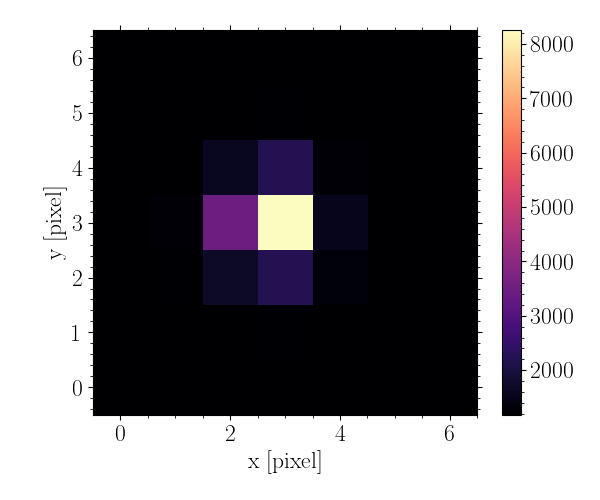

In [38]:
plt.figure(figsize=(6,5))
plt.imshow(imagette, interpolation='nearest', origin='lower', cmap="magma")
plt.colorbar(fraction=0.045)
plt.xlabel("x [pixel]")
plt.ylabel("y [pixel]")
plt.tight_layout()
plt.show()

### Point Spred Function (PSF)

`getPSF()`: The PSF can also be fetched. Above we saved the high resolution PSF to file, but it is also possible to save the diffused PSF. Here we fetch the following:

In [39]:
psf = f.getPSF("highResPSF")

<IPython.core.display.Javascript object>


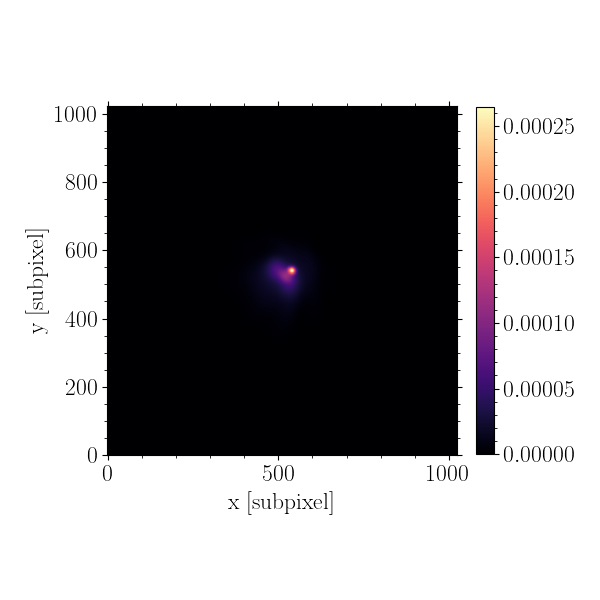

In [40]:
plt.figure(figsize=(6,6))
plt.imshow(psf, interpolation='nearest', origin='lower', cmap="magma")
plt.colorbar(fraction=0.045)
plt.xlabel("x [subpixel]")
plt.ylabel("y [subpixel]")
plt.tight_layout()
plt.show()

`showPSF()`: Again there is an in-build function to show the used PSF:

<IPython.core.display.Javascript object>


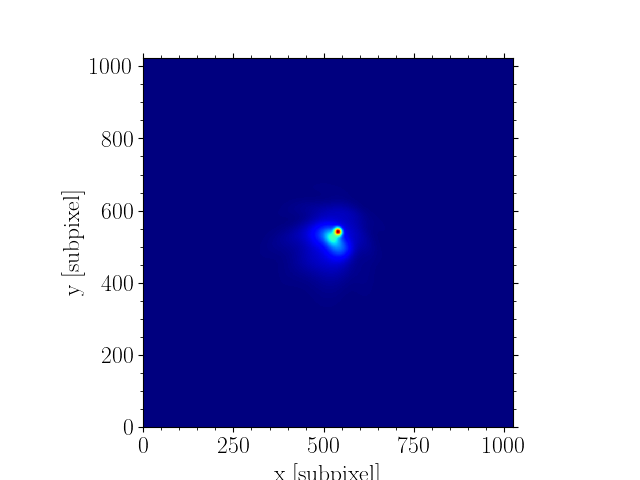

In [41]:
f.showPSF("highResPSF", useTitle=False)

### Pixel maps

`getSmearingMap()`: The smearing map (from a parallel overscan) can be fetched with:

In [42]:
sm = f.getSmearingMap(imageNr)

<IPython.core.display.Javascript object>


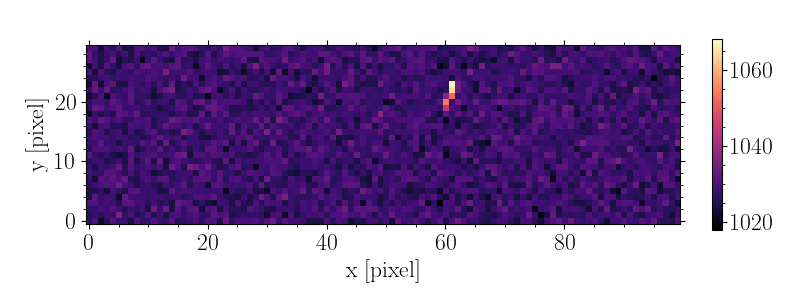

In [43]:
plt.figure(figsize=(8,3))
plt.imshow(sm, interpolation='nearest', origin='lower', cmap="magma")
plt.colorbar(fraction=0.015)
plt.xlabel("x [pixel]")
plt.ylabel("y [pixel]")
plt.tight_layout()
plt.show()

The bias map (from a serial prescan) can be fetched with for the left CCD half with `getBiasMapLeft()` and for the right CCD half with `getBiasMapRight()`. Here we show the former:

In [44]:
bm = f.getBiasMapLeft(imageNr)

<IPython.core.display.Javascript object>


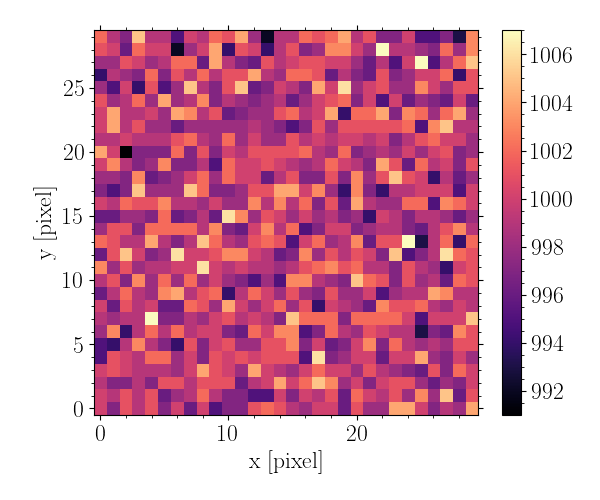

In [45]:
plt.figure(figsize=(6,5))
plt.imshow(bm, interpolation='nearest', origin='lower', cmap="magma")
plt.colorbar(fraction=0.045)
plt.xlabel("x [pixel]")
plt.ylabel("y [pixel]")
plt.tight_layout()
plt.show()

 `getThroughputMap()`: Get the throughput map:

In [46]:
tm = f.getThroughputMap(imageNr)

<IPython.core.display.Javascript object>


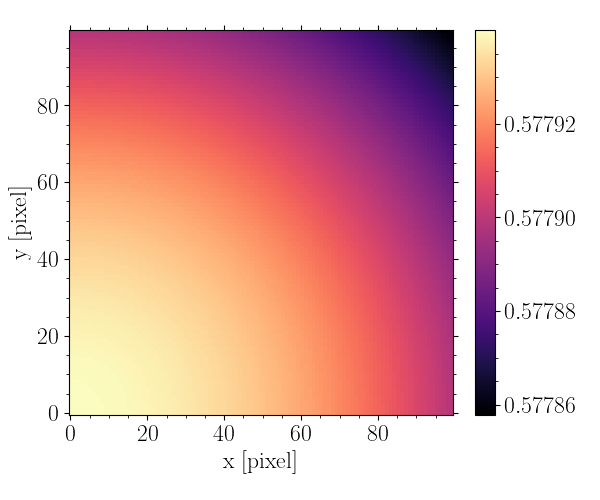

In [47]:
plt.figure(figsize=(6,5))
plt.imshow(tm, interpolation='nearest', origin='lower', cmap="magma")
plt.colorbar(fraction=0.045)
plt.xlabel("x [pixel]")
plt.ylabel("y [pixel]")
plt.tight_layout()
plt.show()

`getPRNU()`: Get the Pixel Response Non-Uniformity (PRNU; which essentially is the flat-field image):

In [48]:
prnu = f.getPRNU()

<IPython.core.display.Javascript object>


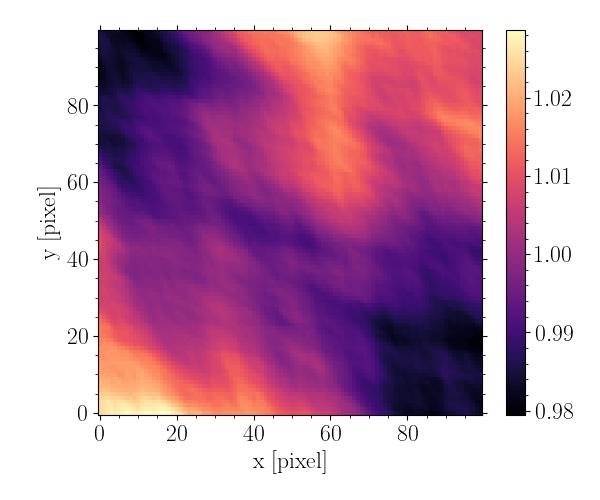

In [49]:
plt.figure(figsize=(6,5))
plt.imshow(prnu, interpolation='nearest', origin='lower', cmap="magma")
plt.colorbar(fraction=0.045)
plt.xlabel("x [pixel]")
plt.ylabel("y [pixel]")
plt.tight_layout()
plt.show()

In [50]:
# Do not exist at the moment!
# irnu = f.getIRNU()
# plt.imshow(irnu, interpolation='nearest', cmap=cm.hot)

#             >>> file = SimFile("Simul01.hdf5")                                                                                                                                                              
#             >>> IRNU = file.getIRNU()                                                                                                                                                                       
#             >>> plt.imshow(IRNU, cmap="hot", interpolation="nearest")                                                                                                                                       
#             >>> plt.colorbar()                                                                                                                                                                              
                                                                                                                                                                                                            
#             To rebin the IRNU to the PRNU:                                                                                                                                                                  
                                                                                                                                                                                                            
#             >>> Nrows, Ncols = 100, 100      # size in pixels of the subfield                                                                                                                               
#             >>> NsubPixels = 16              # 16^2 subpixels in 1 pixel                                                                                                                                    
#             >>> assert(IRNU.shape == (Nrows*NsubPixels, Ncols*NsubPixels))                                                                                                                                  
#             >>> PRNU = IRNU.reshape(Nrows, NsubPixels, Ncols, NsubPixels).sum(axis=3).sum(axis=1) 